Name: Anamika Jagram Lodhi

Roll No: CE22

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





In [ ]:
from google.colab import files
uploaded = files.upload()

# After uploading, you should see the file name in the output.
# If you uploaded 'cardekho_dataset.csv1.csv', then you can proceed.

Saving cardekho_dataset.csv1.csv to cardekho_dataset.csv1.csv


\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# Task 1: Import required libraries

import numpy as np
import matplotlib.pyplot as plt

# Display plots inside Google Colab/Jupyter Notebook
%matplotlib inline

print("NumPy version:", np.__version__)
print("Environment setup completed successfully.")

NumPy version: 2.0.2
Environment setup completed successfully.


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
import pandas as pd
import os
import numpy as np # Added for np.number

# Load dataset
file_path = "cardekho_dataset.csv1.csv"

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please upload 'cardekho_dataset.csv1.csv' to your Colab environment or ensure it's in the correct directory.")
    # You can upload the file using the files tab on the left, or by running:
    # from google.colab import files
    # uploaded = files.upload()
    # For now, we will skip the rest of the operations as the file is missing.
else:
    df = pd.read_csv("cardekho_dataset.csv1.csv")

    # Display first 5 records
    print("First 5 records:")
    display(df.head())

    # Number of rows and columns
    print("\nNumber of rows:", df.shape[0])
    print("Number of columns:", df.shape[1])

    # Display column names
    print("\nColumn names:")
    print(df.columns.tolist())

    # Display data types
    print("\nData types:")
    print(df.dtypes)

    # Numerical and categorical attributes
    numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = df.select_dtypes(include="object").columns.tolist()

    print("\nNumerical attributes:")
    print(numerical_columns)

    print("\nCategorical attributes:")
    print(categorical_columns)

    # Separate target variable
    y = df["selling_price"]

    print("\nTarget variable: selling_price")
    print("Target shape", y.shape)


First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Data types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: selling_price
Target shape (15411,)


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Handle missing values if present
if df.isnull().sum().sum() > 0:
    # Remove rows containing missing values
    df = df.dropna().reset_index(drop=True)
    print("\nMissing-value rows removed.")
else:
    print("\nNo missing values found. No rows were removed.")

# Verify again
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

No missing values found. No rows were removed.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Final dataset shape: (15411, 14)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Task 4: Feature selection

# Create a copy
data = df.copy()

# Current year used for calculating car age
CURRENT_YEAR = 2026 # This variable is not used if we directly use 'vehicle_age'

# Create Car_Age
# Original code tried to use 'Year' which is not in the dataset.
# Using 'vehicle_age' column which already represents the car's age.
data["Car_Age"] = data["vehicle_age"]

# Select meaningful features
# Corrected feature names to match the dataset's column names
# Removed 'Present_Price' and 'Owner' as they are not in the dataset.
selected_features = [
    "km_driven",
    "fuel_type",
    "seller_type",
    "transmission_type",
    "Car_Age"
]

# Corrected target variable name to match the dataset's column name
target = "selling_price"

X = data[selected_features].copy()
y = data[target].copy()

print("Selected features:")
print(selected_features)

print("\nTarget variable:")
print(target)

print("\nPredictor data:")
display(X.head())

print("\nTarget data:")
display(y.head())

Selected features:
['km_driven', 'fuel_type', 'seller_type', 'transmission_type', 'Car_Age']

Target variable:
selling_price

Predictor data:


,km_driven,fuel_type,seller_type,transmission_type,Car_Age
0,120000,Petrol,Individual,Manual,9
1,20000,Petrol,Individual,Manual,5
2,60000,Petrol,Individual,Manual,11
3,37000,Petrol,Individual,Manual,9
4,30000,Diesel,Dealer,Manual,6



Target data:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: One-hot encode categorical variables

categorical_features = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

# Perform one-hot encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

print("Transformed dataset:")
display(X_encoded.head())

print("\nTransformed columns:")
print(X_encoded.columns.tolist())

print("\nData types after encoding:")
print(X_encoded.dtypes)

# Verify that all predictors are numerical
print("\nAre all predictors numerical?")
print(all(np.issubdtype(dtype, np.number) for dtype in X_encoded.dtypes))

Transformed dataset:


,km_driven,Car_Age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,120000,9,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,20000,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,60000,11,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,37000,9,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,30000,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0



Transformed columns:
['km_driven', 'Car_Age', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']

Data types after encoding:
km_driven                         int64
Car_Age                           int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical?
True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Feature engineering

print("Sample Car_Age values:")
# 'Year' column does not exist, displaying 'Car_Age' and 'vehicle_age' instead
display(data[["vehicle_age", "Car_Age"]].head(10))

print("\nMinimum Car Age:", data["Car_Age"].min())
print("Maximum Car Age:", data["Car_Age"].max())

# Check for invalid ages
if (data["Car_Age"] < 0).any():
    print("\nWarning: Some negative car ages were found.")
else:
    print("\nAll calculated car ages are reasonable.")

Sample Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum Car Age: 0
Maximum Car Age: 29

All calculated car ages are reasonable.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

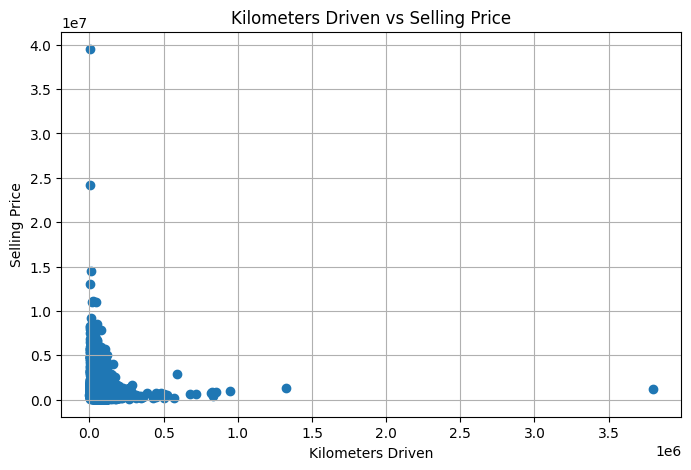

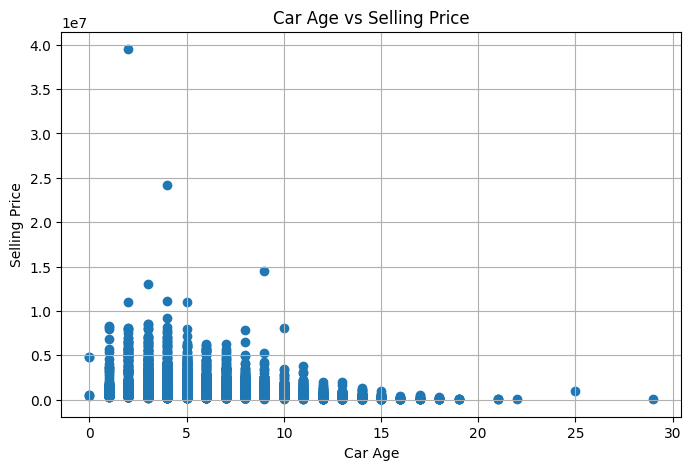

In [ ]:
# Task 7: Exploratory Data Analysis

# Plot 1: km_driven vs selling_price
# 'Present_Price' was not found in the dataset, using 'km_driven' instead.
plt.figure(figsize=(8, 5))
plt.scatter(data["km_driven"], data["selling_price"])
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")
plt.grid(True)
plt.show()

# Plot 2: Car_Age vs selling_price
# 'Kms_Driven' was corrected to 'km_driven', but 'Car_Age' is also a relevant numerical feature.
plt.figure(figsize=(8, 5))
plt.scatter(data["Car_Age"], data["selling_price"])
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")
plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Task 8: Standardization will be performed after train-test splitting.
# This prevents information from the test dataset from influencing training.

print("Standardization formula:")
print("z = (x - mean) / standard deviation")

Standardization formula:
z = (x - mean) / standard deviation


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Train-test split using NumPy

# Convert dataframe to NumPy array
X_all = X_encoded.to_numpy(dtype=float)
y_all = y.to_numpy(dtype=float)

# Fixed random seed
np.random.seed(42)

# Create shuffled indices
indices = np.arange(len(X_all))
np.random.shuffle(indices)

# 80:20 split
split_index = int(0.80 * len(X_all))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

# Create train and test data
Xtrain_raw = X_all[train_indices]
Xtest_raw = X_all[test_indices]

ytrain = y_all[train_indices]
ytest = y_all[test_indices]

print("Training observations:", len(Xtrain_raw))
print("Testing observations:", len(Xtest_raw))

print("\nTraining percentage:",
      len(Xtrain_raw) / len(X_all) * 100, "%")

print("Testing percentage:",
      len(Xtest_raw) / len(X_all) * 100, "%")

Training observations: 12328
Testing observations: 3083

Training percentage: 79.99480890273182 %
Testing percentage: 20.005191097268185 %


In [ ]:
feature_names = X_encoded.columns.tolist()

numerical_features = [
    "km_driven",
    "Car_Age"
]

# Find their column positions
numerical_indices = [
    feature_names.index(feature)
    for feature in numerical_features
]

# Calculate training means and standard deviations ONLY
# from the training data
train_mean = np.mean(Xtrain_raw[:, numerical_indices], axis=0)
train_std = np.std(Xtrain_raw[:, numerical_indices], axis=0)

# Prevent division by zero
train_std[train_std == 0] = 1

# Copy raw matrices
Xtrain = Xtrain_raw.copy()
Xtest = Xtest_raw.copy()

# Standardize numerical predictors
Xtrain[:, numerical_indices] = (
    Xtrain[:, numerical_indices] - train_mean
) / train_std

Xtest[:, numerical_indices] = (
    Xtest[:, numerical_indices] - train_mean
) / train_std

print("Numerical features standardized:")
print(numerical_features)

print("\nTraining means:")
print(train_mean)

print("\nTraining standard deviations:")
print(train_std)

print("\nTarget variable Selling_Price was NOT standardized.")

Numerical features standardized:
['km_driven', 'Car_Age']

Training means:
[5.56928196e+04 6.03244646e+00]

Training standard deviations:
[5.44709544e+04 3.01874714e+00]

Target variable Selling_Price was NOT standardized.


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Task 10: Construct feature and target matrices

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)
print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

print("\nNumber of predictor columns:", Xtrain.shape[1])
print("Number of training observations:", Xtrain.shape[0])
print("Number of testing observations:", Xtest.shape[0])

Xtrain shape: (12328, 9)
ytrain shape: (12328,)
Xtest shape: (3083, 9)
ytest shape: (3083,)

Number of predictor columns: 9
Number of training observations: 12328
Number of testing observations: 3083


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Add bias/intercept column

Xtrain_bias = np.column_stack([
    np.ones(Xtrain.shape[0]),
    Xtrain
])

Xtest_bias = np.column_stack([
    np.ones(Xtest.shape[0]),
    Xtest
])

print("Xtrain before bias:", Xtrain.shape)
print("Xtrain after bias:", Xtrain_bias.shape)

print("\nXtest before bias:", Xtest.shape)
print("Xtest after bias:", Xtest_bias.shape)

print("\nFirst five rows of training matrix:")
print(Xtrain_bias[:5])

Xtrain before bias: (12328, 9)
Xtrain after bias: (12328, 10)

Xtest before bias: (3083, 9)
Xtest after bias: (3083, 10)

First five rows of training matrix:
[[ 1.          0.31773228  1.9768312   0.          0.          0.
   1.          0.          0.          1.        ]
 [ 1.          0.04235616 -0.67327483  1.          0.          0.
   0.          1.          0.          1.        ]
 [ 1.          0.73997566  0.32051493  1.          0.          0.
   0.          0.          0.          1.        ]
 [ 1.         -0.93981866 -1.66706459  0.          0.          0.
   1.          0.          0.          0.        ]
 [ 1.          0.11578979  1.64556795  0.          0.          0.
   1.          0.          0.          1.        ]]


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 12: Ordinary Least Squares implementation

def ols(X, y):
    """
    Implements Ordinary Least Squares using the normal equation:

    beta = (X^T X)^(-1) X^T y
    """

    # X transpose multiplied by X
    XTX = X.T @ X

    # X transpose multiplied by y
    XTy = X.T @ y

    # Calculate inverse of XTX
    XTX_inv = np.linalg.inv(XTX)

    # Calculate regression coefficients
    beta = XTX_inv @ XTy

    return beta


# Train model
beta = ols(Xtrain_bias, ytrain)

print("Regression coefficient vector:")
print(beta)

print("\nNumber of coefficients:", len(beta))

Regression coefficient vector:
[1364952.28914411  -32044.22221417 -185206.92470149  420395.36269805
  511482.78858047  179332.49425458   -2380.03566546 -107967.82994885
 -128656.58427525 -942493.230646  ]

Number of coefficients: 10


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Task 13: Check whether X^T X is singular

XTX = Xtrain_bias.T @ Xtrain_bias

det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

# Check determinant
if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("Possible multicollinearity or redundant features.")
else:
    print("\nX^T X is not singular.")
    print("The OLS normal equation can be applied.")

Determinant of X^T X:
7.822735957616861e+28

X^T X is not singular.
The OLS normal equation can be applied.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Display regression coefficients

print("Regression coefficients:\n")

print("Intercept (Beta 0):", beta[0])

for feature, coefficient in zip(feature_names, beta[1:]):
    print(f"{feature}: {coefficient:.6f}")

Regression coefficients:

Intercept (Beta 0): 1364952.2891441062
km_driven: -32044.222214
Car_Age: -185206.924701
fuel_type_Diesel: 420395.362698
fuel_type_Electric: 511482.788580
fuel_type_LPG: 179332.494255
fuel_type_Petrol: -2380.035665
seller_type_Individual: -107967.829949
seller_type_Trustmark Dealer: -128656.584275
transmission_type_Manual: -942493.230646


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Interpret coefficient signs and magnitudes

coefficient_table = pd.DataFrame({
    "Feature": ["Intercept"] + feature_names,
    "Coefficient": beta
})

coefficient_table["Sign"] = coefficient_table["Coefficient"].apply(
    lambda x: "Positive" if x > 0 else "Negative" if x < 0 else "Zero"
)

print("Coefficient interpretation:")
display(coefficient_table)

# Rank predictor coefficients by absolute magnitude
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta[1:],
    "Absolute_Coefficient": np.abs(beta[1:])
})

importance = importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nFeatures ranked by absolute standardized coefficient:")
display(importance)

Coefficient interpretation:


,Feature,Coefficient,Sign
0,Intercept,1.364952e+06,Positive
1,km_driven,-3.204422e+04,Negative
2,Car_Age,-1.852069e+05,Negative
3,fuel_type_Diesel,4.203954e+05,Positive
4,fuel_type_Electric,5.114828e+05,Positive
5,fuel_type_LPG,1.793325e+05,Positive
6,fuel_type_Petrol,-2.380036e+03,Negative
7,seller_type_Individual,-1.079678e+05,Negative
8,seller_type_Trustmark Dealer,-1.286566e+05,Negative
9,transmission_type_Manual,-9.424932e+05,Negative



Features ranked by absolute standardized coefficient:


,Feature,Coefficient,Absolute_Coefficient
8,transmission_type_Manual,-942493.230646,942493.230646
3,fuel_type_Electric,511482.788580,511482.788580
2,fuel_type_Diesel,420395.362698,420395.362698
1,Car_Age,-185206.924701,185206.924701
4,fuel_type_LPG,179332.494255,179332.494255
7,seller_type_Trustmark Dealer,-128656.584275,128656.584275
6,seller_type_Individual,-107967.829949,107967.829949
0,km_driven,-32044.222214,32044.222214
5,fuel_type_Petrol,-2380.035665,2380.035665


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Predict selling prices

# Prediction equation:
# y_hat = X_test * beta

y_pred = Xtest_bias @ beta

# Display actual vs predicted prices
comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred,
    "Error": ytest - y_pred
})

print("Sample comparison of actual and predicted prices:")
display(comparison.head(10))

Sample comparison of actual and predicted prices:


,Actual Selling Price,Predicted Selling Price,Error
0,4450000.0,1.989451e+06,2.460549e+06
1,1290000.0,1.651511e+06,-3.615109e+05
2,485000.0,7.794883e+05,-2.944883e+05
3,400000.0,9.242533e+05,-5.242533e+05
4,800000.0,1.568441e+06,-7.684405e+05
5,150000.0,-1.414290e+05,2.914290e+05
6,650000.0,8.511355e+05,-2.011355e+05
7,325000.0,2.754636e+05,4.953636e+04
8,300000.0,5.385211e+05,-2.385211e+05
9,925000.0,8.370167e+05,8.798328e+04


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Task 17: Calculate residuals and RSS

# Residuals
residuals = ytest - y_pred

# Residual Sum of Squares
RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nMean Squared Error:")
print(np.mean(residuals ** 2))

print("\nMean Absolute Error:")
print(np.mean(np.abs(residuals)))

Residual Sum of Squares (RSS):
1681040269901908.8

Mean Squared Error:
545261196854.333

Mean Absolute Error:
350816.05350076937


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Task 18: Calculate R-squared

# Total Sum of Squares
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# R-squared
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR-squared (R²):")
print(R2)

Total Sum of Squares (TSS):
2407385049859876.5

R-squared (R²):
0.30171524908333425


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


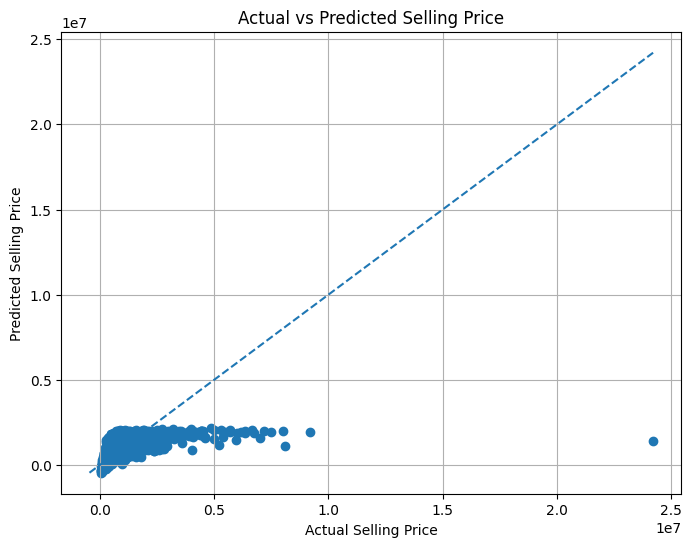

In [ ]:
# Task 19: Actual vs Predicted Selling Price

plt.figure(figsize=(8, 6))

plt.scatter(ytest, y_pred)

# Perfect prediction reference line
min_price = min(ytest.min(), y_pred.min())
max_price = max(ytest.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()

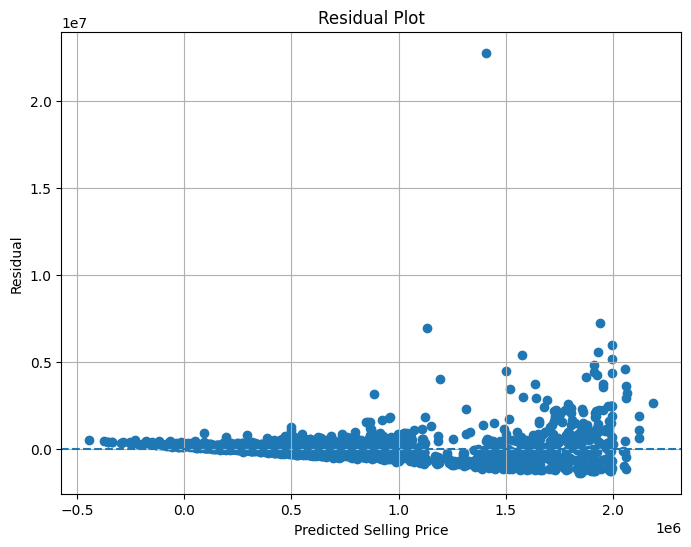

In [ ]:
# Residual plot

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [ ]:
# Identify observations with relatively large errors

comparison["Absolute_Error"] = np.abs(comparison["Error"])

large_errors = comparison.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

print("Observations with the largest prediction errors:")
display(large_errors)

Observations with the largest prediction errors:


,Actual Selling Price,Predicted Selling Price,Error,Absolute_Error
2796,24200000.0,1.409121e+06,2.279088e+07,2.279088e+07
2362,9200000.0,1.937217e+06,7.262783e+06,7.262783e+06
1552,8100000.0,1.134269e+06,6.965731e+06,6.965731e+06
1382,8000000.0,1.995334e+06,6.004666e+06,6.004666e+06
841,7500000.0,1.930382e+06,5.569618e+06,5.569618e+06
246,7000000.0,1.573735e+06,5.426265e+06,5.426265e+06
1286,7199000.0,1.995334e+06,5.203666e+06,5.203666e+06
1493,6750000.0,1.913392e+06,4.836608e+06,4.836608e+06
1092,6645000.0,2.057274e+06,4.587726e+06,4.587726e+06
2534,5975000.0,1.500029e+06,4.474971e+06,4.474971e+06


### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.